# ICPRAM 2026
## Facial Emotion Recognition: a comparative study with cross-corpus and multi-corpus training

This paper presents a systematic experimental study of FER generalization under cross-corpus and multi-corpus training. Rather than introducing a novel architecture, we focus on analyzing how different learning strategies and dataset combinations influence model robustness, efficiency, and failure modes across domains. 

We compare a lightweight convolutional baseline against a transformer-based FER model and a domain adaptation strategy, and we conduct ablation experiments to quantify the marginal utility of small datasets in large-scale training setups.

Even without changing seeds:
- GPU/MPS is not dterministic
- The real order of parallel operations changes
- Small numeric differences accumulate
- Networks with attention + softmax + AdamW amplify the differences

Result: slightly different runs, normally ±0.1–1%.

In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Almost deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 8
set_seed(SEED)

2.14.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
# built-in imports
import sys
import os
# src imports
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_affectnet, load_ck, load_fer2013, load_rafbd, filter_emotions

affect = filter_emotions(load_affectnet()) 
ck = filter_emotions(load_ck())
ck['pixels'] = ck['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
fer = filter_emotions(load_fer2013())
fer['pixels'] = fer['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
raf = filter_emotions(load_rafbd())

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/krazmic/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:04<00:00,  1.69it/s]


Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:00<00:00, 5683.29it/s]


In [3]:
#print(ck.pixels.iloc[0])
#print(fer.pixels.iloc[0])
#print(raf.pixels.iloc[0])
#print(affect.pixels.iloc[0])

### Data Preprocessing

In [4]:
from transformers import MobileViTImageProcessor, MobileViTForImageClassification
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

LABEL_MAP = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6
}


class ImageDataset(Dataset):
    def __init__(self, df, feature_extractor):
        self.df = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---------
        # Load image
        # ---------
        if "pixels" in row and row["pixels"] is not None:
            img = row["pixels"]

            # FER / CK are grayscale → convert to RGB
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)

            image = Image.fromarray(img.astype(np.uint8))

        else:
            image = Image.open(row["filename"]).convert("RGB")

        label = LABEL_MAP[row["label"]]

        inputs = self.feature_extractor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }
    

def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

num_labels = len(LABEL_MAP)



In [5]:

from transformers import AdamW, get_cosine_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report
from src.evaluation import plot_confusion_matrix #, plot_training_history
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

---- MPS DEVICE ----


In [6]:
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_affectnet_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_affectnet_best")
model.to(device)

val_ds   = ImageDataset(affect_val, feature_extractor)
test_ds = ImageDataset(affect_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

### AffectNet

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 001 | Train loss: 1.9177 | Val loss: 1.8350 | Train acc: 0.2322 | Val acc: 0.3698
Epoch 002 | Train loss: 1.5691 | Val loss: 1.4063 | Train acc: 0.3956 | Val acc: 0.4845
Epoch 003 | Train loss: 1.2237 | Val loss: 1.0396 | Train acc: 0.5147 | Val acc: 0.5167
Epoch 004 | Train loss: 1.0432 | Val loss: 0.9735 | Train acc: 0.5668 | Val acc: 0.5636
Epoch 005 | Train loss: 0.9569 | Val loss: 0.7409 | Train acc: 0.6003 | Val acc: 0.5954
Epoch 006 | Train loss: 0.8806 | Val loss: 0.9458 | Train acc: 0.6490 | Val acc: 0.6226
Epoch 007 | Train loss: 0.8035 | Val loss: 0.3337 | Train acc: 0.6846 | Val acc: 0.6033
Epoch 008 | Train loss: 0.7393 | Val loss: 1.0687 | Train acc: 0.7110 | Val acc: 0.5916
Epoch 009 | Train loss: 0.6606 | Val loss: 0.7848 | Train acc: 0.7454 | Val acc: 0.6302
Epoch 010 | Train loss: 0.6210 | Val loss: 0.4494 | Train acc: 0.7657 | Val acc: 0.6185
Epoch 011 | Train loss: 0.5465 | Val loss: 1.2187 | Train acc: 0.7949 | Val acc: 0.6355
Epoch 012 | Train loss: 0.4784 |

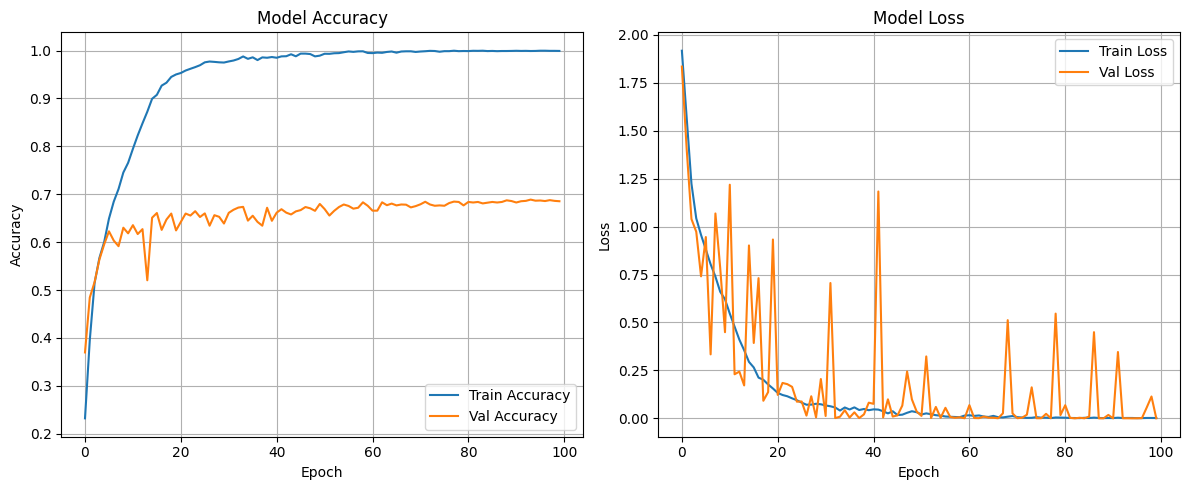

Validation accuracy on Affect Net: 0.6889
Test accuracy on Affect Net: 0.6683


In [7]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(affect_train, feature_extractor)
val_ds   = ImageDataset(affect_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)



model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_affectnet_best")
        feature_extractor.save_pretrained("mobilevit_affectnet_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_affectnet_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_affectnet_best")
model.to(device)

val_ds   = ImageDataset(affect_val, feature_extractor)
test_ds = ImageDataset(affect_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on Affect Net: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on Affect Net: {acc:.4f}")



Validation accuracy on Affect Net: 0.6889
Test accuracy on Affect Net: 0.6683
              precision    recall  f1-score   support

           0       0.53      0.61      0.57       516
           1       0.50      0.48      0.49       374
           2       0.57      0.51      0.54       499
           3       0.90      0.85      0.87       811
           4       0.55      0.50      0.52       475
           5       0.61      0.60      0.61       576
           6       0.79      0.88      0.83       711

    accuracy                           0.67      3962
   macro avg       0.64      0.63      0.63      3962
weighted avg       0.67      0.67      0.67      3962



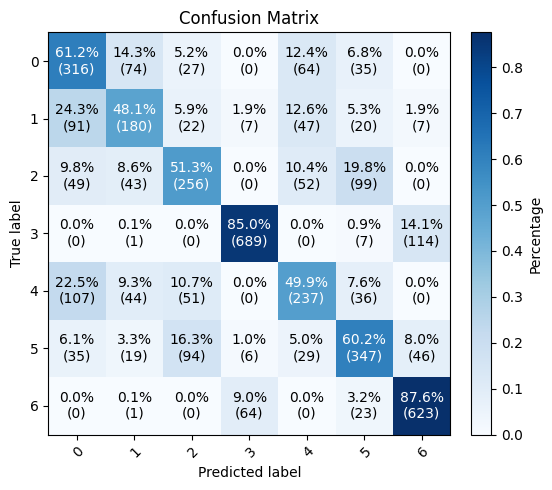

In [8]:
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_affectnet_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_affectnet_best")
model.to(device)

val_ds   = ImageDataset(affect_val, feature_extractor)
test_ds = ImageDataset(affect_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on Affect Net: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on Affect Net: {acc:.4f}")

print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)


Validation accuracy on RAF-DB test: 0.1711
              precision    recall  f1-score   support

           0       0.18      0.50      0.26       162
           1       0.07      0.20      0.10       160
           2       0.04      0.35      0.08        74
           3       0.00      0.00      0.00      1185
           4       0.24      0.75      0.36       478
           5       0.56      0.07      0.12       329
           6       0.50      0.01      0.02       680

    accuracy                           0.17      3068
   macro avg       0.23      0.27      0.13      3068
weighted avg       0.22      0.17      0.09      3068



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

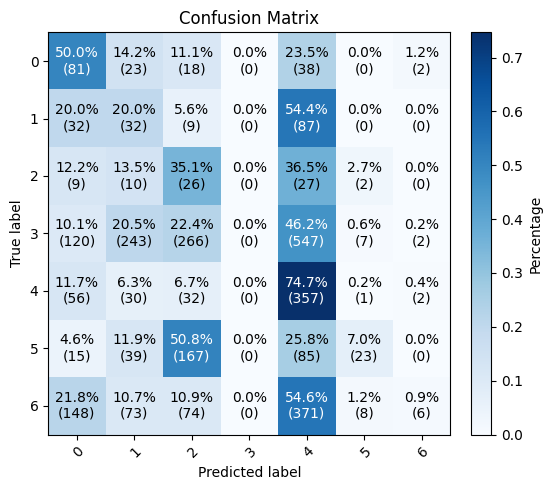

In [9]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK test: 0.1186
              precision    recall  f1-score   support

           0       0.09      0.62      0.15        45
           1       0.31      0.46      0.37        59
           2       0.06      0.56      0.10        25
           3       0.00      0.00      0.00        69
           4       0.10      0.82      0.18        28
           5       0.54      0.18      0.27        83
           6       0.00      0.00      0.00       593

    accuracy                           0.12       902
   macro avg       0.16      0.38      0.15       902
weighted avg       0.08      0.12      0.07       902



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

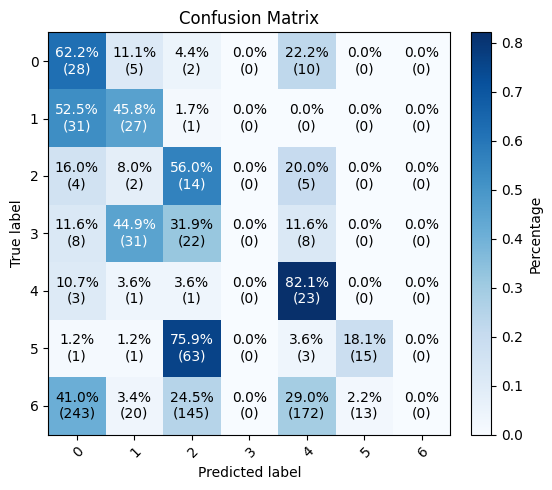

In [10]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on FER2013 test: 0.2031
              precision    recall  f1-score   support

           0       0.27      0.41      0.32      4953
           1       0.03      0.51      0.06       547
           2       0.19      0.34      0.24      5121
           3       0.00      0.00      0.00      8989
           4       0.29      0.40      0.34      6077
           5       0.43      0.20      0.27      4002
           6       0.00      0.00      0.00      6198

    accuracy                           0.20     35887
   macro avg       0.17      0.27      0.18     35887
weighted avg       0.16      0.20      0.17     35887



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

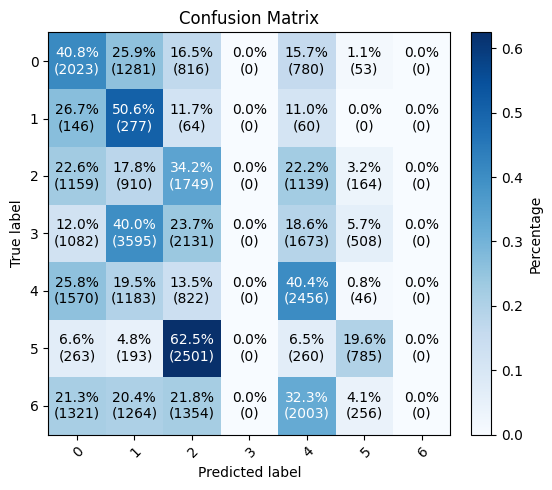

In [11]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

## UMAP

In [12]:

import numpy as np
import torch
import torch.nn.functional as F


def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            batch_labels = batch["labels"].cpu().numpy()

            outputs = model(
                pixel_values=pixel_values,
                output_hidden_states=True
            )

            # Last hidden state: [B, C, H, W]
            feats = outputs.hidden_states[-1]

            # Global Average Pooling
            feats = F.adaptive_avg_pool2d(feats, 1).squeeze(-1).squeeze(-1)

            embeddings.append(feats.cpu().numpy())
            labels.extend(batch_labels)

    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.array(labels)

    return embeddings, labels




outputs = model(pixel_values, output_hidden_states=True)
features = outputs.hidden_states[-1]

affect_ds = ImageDataset(affect_test, feature_extractor)
raf_ds    = ImageDataset(raf, feature_extractor)

affect_loader = DataLoader(affect_ds, batch_size=32, shuffle=False)
raf_loader    = DataLoader(raf_ds, batch_size=32, shuffle=False)

X_affect, y_affect = extract_embeddings(model, affect_loader, device)
X_raf, y_raf       = extract_embeddings(model, raf_loader, device)

X = np.vstack([X_affect, X_raf])
y = np.concatenate([y_affect, y_raf])

domain = np.array(
    ["AffectNet"] * len(X_affect) +
    ["RAF-DB"] * len(X_raf)
)



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


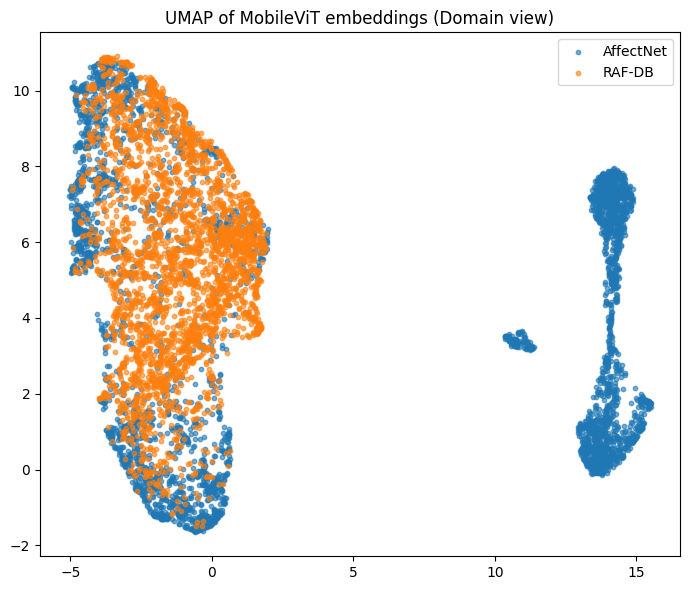

In [13]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
for d in ["AffectNet", "RAF-DB"]:
    idx = domain == d
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        s=10,
        alpha=0.6,
        label=d
    )

plt.legend()
plt.title("UMAP of MobileViT embeddings (Domain view)")
plt.tight_layout()
plt.show()


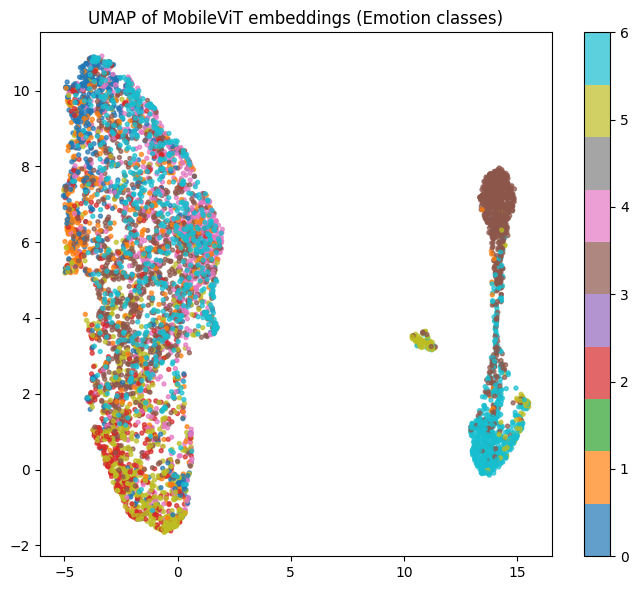

In [14]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(7))
plt.title("UMAP of MobileViT embeddings (Emotion classes)")
plt.tight_layout()
plt.show()


## RAF-DB

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9456 | Val loss: 1.9526 | Train acc: 0.1442 | Val acc: 0.1580
Epoch 002 | Train loss: 1.9254 | Val loss: 1.8960 | Train acc: 0.2453 | Val acc: 0.3322
Epoch 003 | Train loss: 1.8670 | Val loss: 1.8627 | Train acc: 0.4070 | Val acc: 0.4104
Epoch 004 | Train loss: 1.6942 | Val loss: 1.7019 | Train acc: 0.4899 | Val acc: 0.4349
Epoch 005 | Train loss: 1.4281 | Val loss: 1.3479 | Train acc: 0.5414 | Val acc: 0.5814
Epoch 006 | Train loss: 1.1780 | Val loss: 0.8906 | Train acc: 0.6256 | Val acc: 0.5831
Epoch 007 | Train loss: 0.9898 | Val loss: 0.8182 | Train acc: 0.6810 | Val acc: 0.6010
Epoch 008 | Train loss: 0.8403 | Val loss: 1.2484 | Train acc: 0.7267 | Val acc: 0.5033
Epoch 009 | Train loss: 0.7122 | Val loss: 0.6736 | Train acc: 0.7671 | Val acc: 0.6107
Epoch 010 | Train loss: 0.5901 | Val loss: 0.6554 | Train acc: 0.8115 | Val acc: 0.6042
Epoch 011 | Train loss: 0.4952 | Val loss: 0.6248 | Train acc: 0.8395 | Val acc: 0.6450
Epoch 012 |

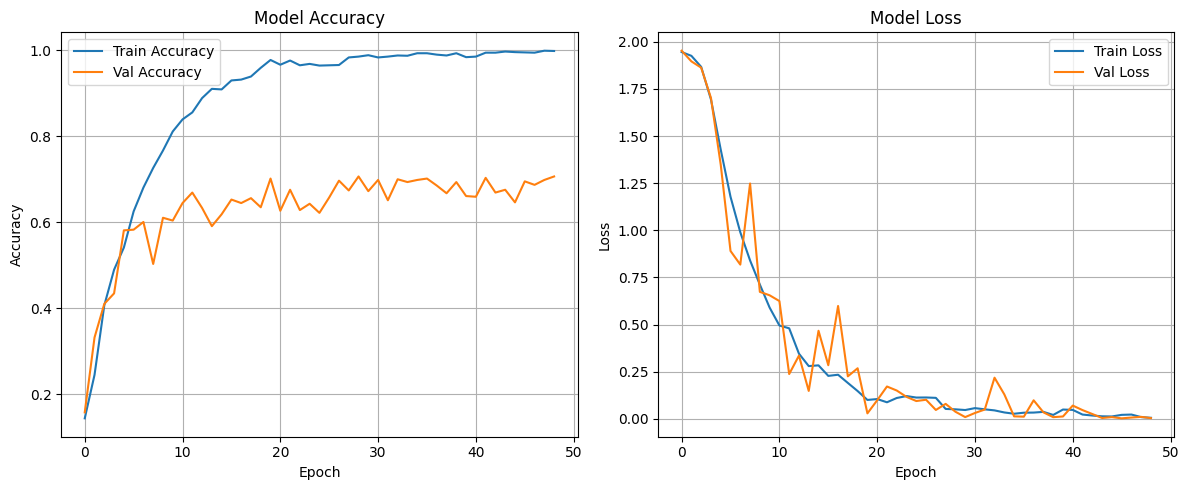

In [15]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(raf_train, feature_extractor)
val_ds   = ImageDataset(raf_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_rafdb_best")
        feature_extractor.save_pretrained("mobilevit_rafdb_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)


 

Validation accuracy on RAF-DBt: 0.7068
Test accuracy on RAF-DB: 0.6840
              precision    recall  f1-score   support

           0       0.47      0.35      0.40        49
           1       0.70      0.15      0.24        48
           2       0.30      0.27      0.29        22
           3       0.83      0.82      0.83       356
           4       0.60      0.65      0.62       143
           5       0.64      0.65      0.64        99
           6       0.61      0.74      0.67       204

    accuracy                           0.68       921
   macro avg       0.59      0.52      0.53       921
weighted avg       0.69      0.68      0.67       921



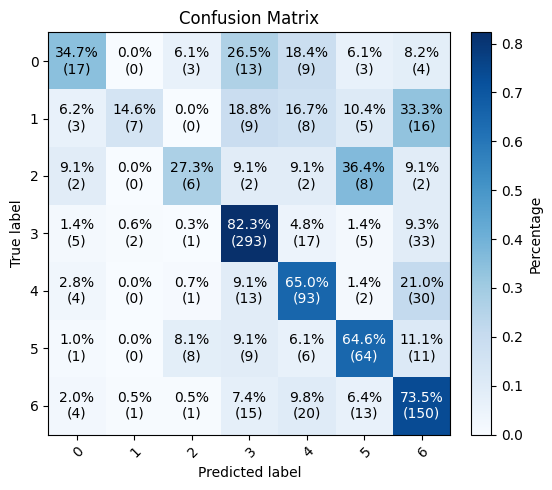

In [16]:
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_rafdb_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_rafdb_best")
model.to(device)


val_ds   = ImageDataset(raf_val, feature_extractor)
test_ds = ImageDataset(raf_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DBt: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on RAF-DB: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK test: 0.7162
              precision    recall  f1-score   support

           0       0.02      0.02      0.02        45
           1       0.48      0.25      0.33        59
           2       0.00      0.00      0.00        25
           3       0.86      0.74      0.80        69
           4       0.10      0.11      0.10        28
           5       0.51      0.96      0.67        83
           6       0.86      0.84      0.85       593

    accuracy                           0.72       902
   macro avg       0.41      0.42      0.40       902
weighted avg       0.72      0.72      0.71       902



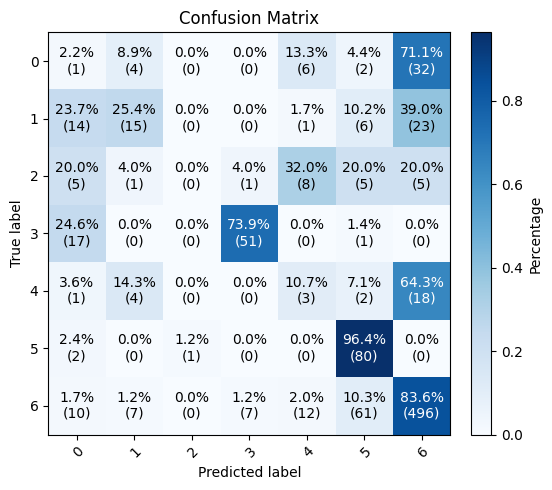

In [17]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on FER2013 test: 0.4054
              precision    recall  f1-score   support

           0       0.35      0.17      0.23      4953
           1       0.03      0.08      0.04       547
           2       0.21      0.05      0.09      5121
           3       0.71      0.59      0.65      8989
           4       0.31      0.33      0.32      6077
           5       0.42      0.70      0.52      4002
           6       0.33      0.53      0.41      6198

    accuracy                           0.41     35887
   macro avg       0.34      0.35      0.32     35887
weighted avg       0.41      0.41      0.39     35887



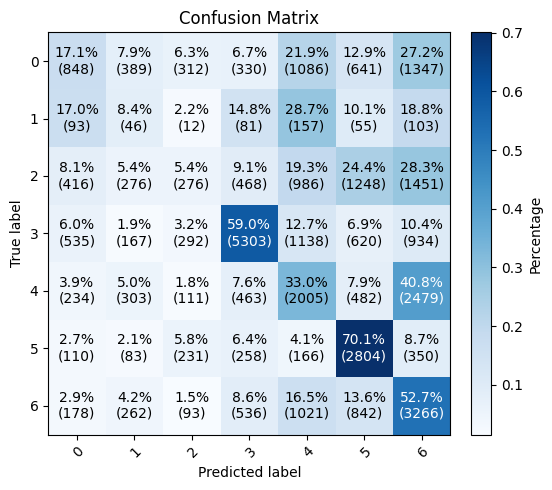

In [18]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.2018
              precision    recall  f1-score   support

           0       0.22      0.10      0.14      1718
           1       0.11      0.05      0.07      1248
           2       0.16      0.34      0.21      1664
           3       0.62      0.08      0.14      2704
           4       0.16      0.50      0.24      1584
           5       0.31      0.39      0.34      1920
           6       0.26      0.04      0.08      2368

    accuracy                           0.20     13206
   macro avg       0.26      0.22      0.17     13206
weighted avg       0.30      0.20      0.17     13206



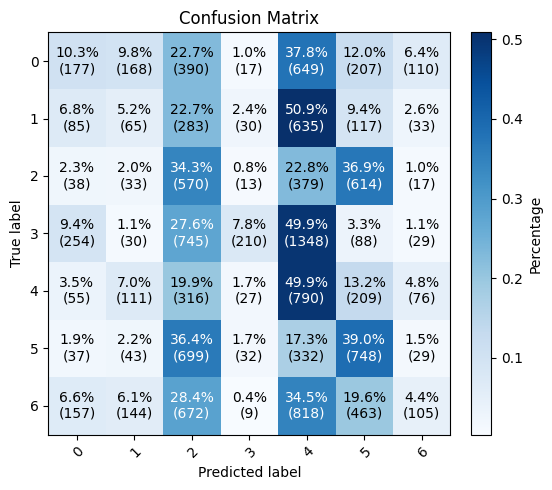

In [19]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

### CK+

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9480 | Val loss: 1.9602 | Train acc: 0.1311 | Val acc: 0.1713
Epoch 002 | Train loss: 1.9327 | Val loss: 1.9331 | Train acc: 0.1689 | Val acc: 0.2873
Epoch 003 | Train loss: 1.9115 | Val loss: 1.9402 | Train acc: 0.3533 | Val acc: 0.3039
Epoch 004 | Train loss: 1.8701 | Val loss: 1.8680 | Train acc: 0.5444 | Val acc: 0.5691
Epoch 005 | Train loss: 1.8043 | Val loss: 1.8869 | Train acc: 0.6844 | Val acc: 0.6409
Epoch 006 | Train loss: 1.6731 | Val loss: 1.8867 | Train acc: 0.6911 | Val acc: 0.6575
Epoch 007 | Train loss: 1.4170 | Val loss: 1.5652 | Train acc: 0.7422 | Val acc: 0.6243
Epoch 008 | Train loss: 1.0606 | Val loss: 1.2208 | Train acc: 0.8356 | Val acc: 0.8066
Epoch 009 | Train loss: 0.8157 | Val loss: 1.3601 | Train acc: 0.8622 | Val acc: 0.3757
Epoch 010 | Train loss: 0.5824 | Val loss: 0.7712 | Train acc: 0.8867 | Val acc: 0.3757
Epoch 011 | Train loss: 0.4857 | Val loss: 0.8857 | Train acc: 0.8778 | Val acc: 0.5635
Epoch 012 |

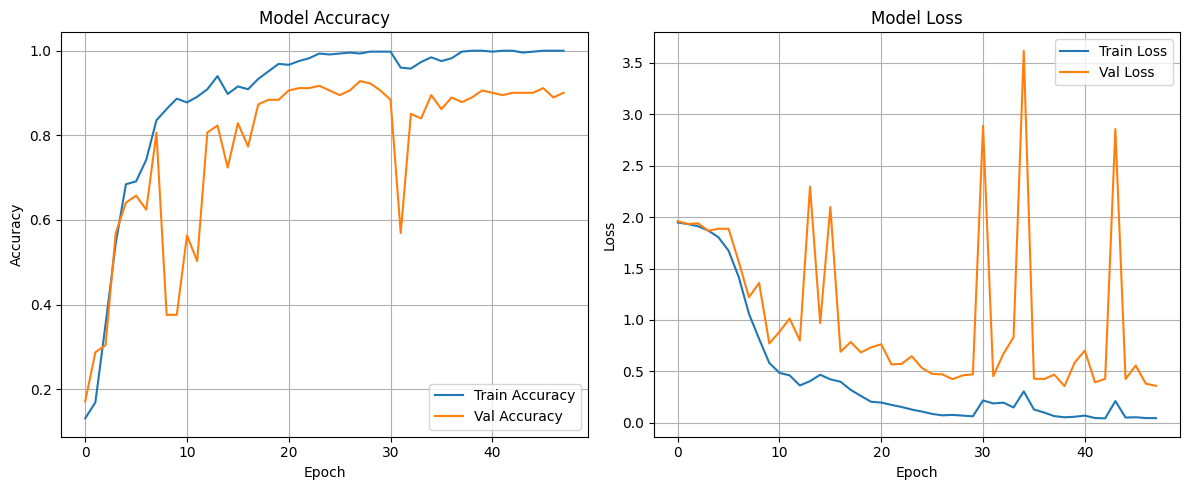

Validation accuracy on CK: 0.9282
Test accuracy on CK: 0.9077
              precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.93      0.78      0.85        18
           2       0.62      0.71      0.67         7
           3       0.95      0.95      0.95        21
           4       0.50      0.25      0.33         8
           5       1.00      1.00      1.00        25
           6       0.94      0.98      0.96       178

    accuracy                           0.91       271
   macro avg       0.77      0.72      0.74       271
weighted avg       0.90      0.91      0.90       271



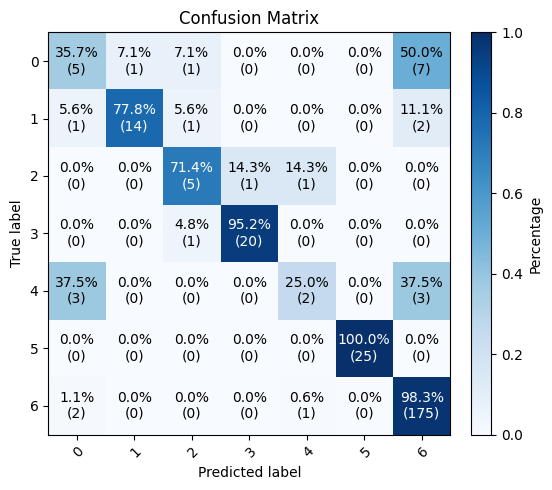

In [20]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(ck_train, feature_extractor)
val_ds   = ImageDataset(ck_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_ck_best")
        feature_extractor.save_pretrained("mobilevit_ck_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_ck_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_ck_best")
model.to(device)
 
val_ds   = ImageDataset(ck_val, feature_extractor)
test_ds = ImageDataset(ck_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on CK: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK: 0.9282
Test accuracy on CK: 0.9077
              precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.93      0.78      0.85        18
           2       0.62      0.71      0.67         7
           3       0.95      0.95      0.95        21
           4       0.50      0.25      0.33         8
           5       1.00      1.00      1.00        25
           6       0.94      0.98      0.96       178

    accuracy                           0.91       271
   macro avg       0.77      0.72      0.74       271
weighted avg       0.90      0.91      0.90       271



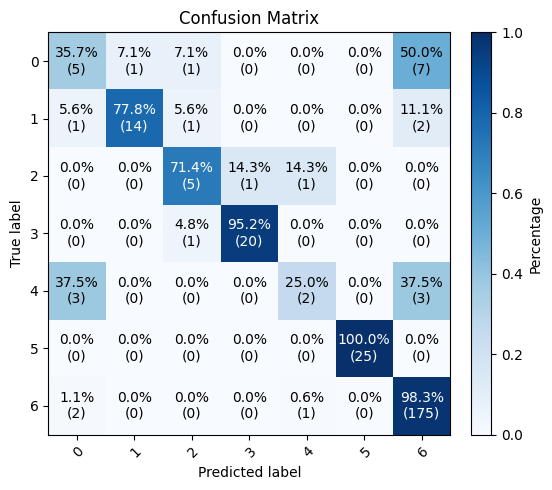

In [21]:
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_ck_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_ck_best")
model.to(device)
 
val_ds   = ImageDataset(ck_val, feature_extractor)
test_ds = ImageDataset(ck_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on CK: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

In [ ]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on RAF-DB test: 0.1610
              precision    recall  f1-score   support

           0       0.01      0.02      0.02       162
           1       0.09      0.09      0.09       160
           2       0.18      0.26      0.21        74
           3       0.44      0.04      0.07      1185
           4       0.14      0.69      0.24       478
           5       0.21      0.02      0.03       329
           6       0.39      0.11      0.17       680

    accuracy                           0.16      3068
   macro avg       0.21      0.17      0.12      3068
weighted avg       0.31      0.16      0.12      3068



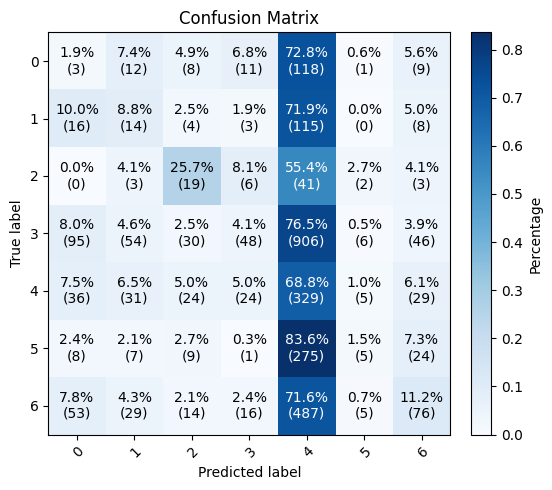

In [ ]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.1243
              precision    recall  f1-score   support

           0       0.16      0.01      0.01      1718
           1       0.10      0.01      0.02      1248
           2       0.14      0.00      0.01      1664
           3       0.00      0.00      0.00      2704
           4       0.12      0.96      0.21      1584
           5       0.35      0.04      0.08      1920
           6       0.14      0.01      0.01      2368

    accuracy                           0.12     13206
   macro avg       0.14      0.15      0.05     13206
weighted avg       0.14      0.12      0.04     13206



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

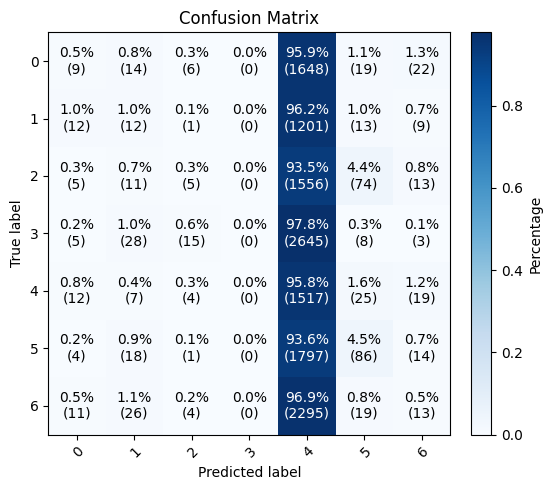

In [ ]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

### FER2013

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9141 | Val loss: 1.8082 | Train acc: 0.2224 | Val acc: 0.3564
Epoch 002 | Train loss: 1.5877 | Val loss: 1.4964 | Train acc: 0.4250 | Val acc: 0.4964
Epoch 003 | Train loss: 1.2746 | Val loss: 1.3954 | Train acc: 0.5352 | Val acc: 0.5517
Epoch 004 | Train loss: 1.1278 | Val loss: 1.1245 | Train acc: 0.5886 | Val acc: 0.5853
Epoch 005 | Train loss: 1.0371 | Val loss: 0.8798 | Train acc: 0.6197 | Val acc: 0.5868
Epoch 006 | Train loss: 0.9707 | Val loss: 0.7056 | Train acc: 0.6446 | Val acc: 0.5917
Epoch 007 | Train loss: 0.9156 | Val loss: 0.7315 | Train acc: 0.6609 | Val acc: 0.5834
Epoch 008 | Train loss: 0.8623 | Val loss: 0.9244 | Train acc: 0.6831 | Val acc: 0.5476
Epoch 009 | Train loss: 0.8105 | Val loss: 0.8010 | Train acc: 0.7045 | Val acc: 0.6091
Epoch 010 | Train loss: 0.7751 | Val loss: 1.0775 | Train acc: 0.7188 | Val acc: 0.6095
Epoch 011 | Train loss: 0.7236 | Val loss: 0.7654 | Train acc: 0.7372 | Val acc: 0.5766
Epoch 012 |

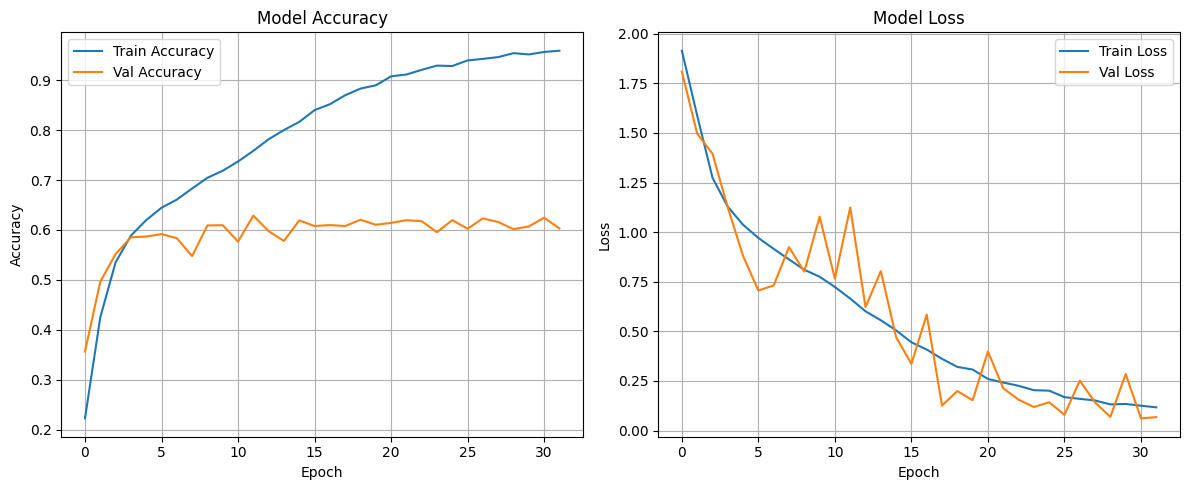

Validation accuracy on FER2013: 0.6287
Test accuracy on FER2013: 0.6138


In [ ]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(fer_train, feature_extractor)
val_ds   = ImageDataset(fer_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_fer_best")
        feature_extractor.save_pretrained("mobilevit_fer_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)



Validation accuracy on FER2013: 0.6287
Test accuracy on FER2013: 0.6138
              precision    recall  f1-score   support

           0       0.51      0.52      0.51      1486
           1       0.39      0.39      0.39       164
           2       0.46      0.39      0.42      1536
           3       0.82      0.84      0.83      2697
           4       0.49      0.52      0.50      1823
           5       0.78      0.69      0.73      1201
           6       0.56      0.61      0.58      1860

    accuracy                           0.61     10767
   macro avg       0.57      0.57      0.57     10767
weighted avg       0.61      0.61      0.61     10767



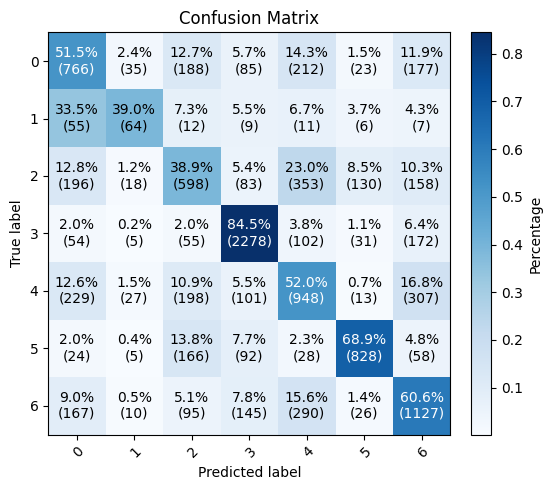

In [ ]:
from src.evaluation import plot_confusion_matrix
from sklearn.metrics import classification_report
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_fer_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_fer_best")
model.to(device)
 
val_ds   = ImageDataset(fer_val, feature_extractor)
test_ds = ImageDataset(fer_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on FER2013: {acc:.4f}")

print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)


Validation accuracy on RAF-DB test: 0.4433
              precision    recall  f1-score   support

           0       0.18      0.48      0.26       162
           1       0.21      0.04      0.07       160
           2       0.07      0.19      0.10        74
           3       0.68      0.62      0.65      1185
           4       0.31      0.38      0.34       478
           5       0.71      0.14      0.23       329
           6       0.44      0.45      0.44       680

    accuracy                           0.44      3068
   macro avg       0.37      0.33      0.30      3068
weighted avg       0.51      0.44      0.45      3068



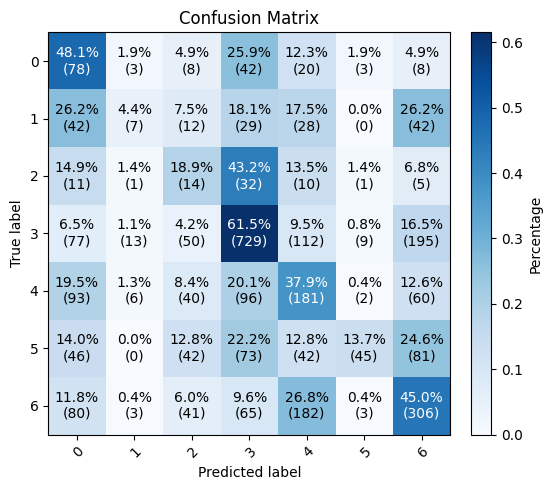

In [ ]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.1670
              precision    recall  f1-score   support

           0       0.14      0.71      0.24      1718
           1       0.00      0.00      0.00      1248
           2       0.12      0.06      0.08      1664
           3       0.34      0.10      0.15      2704
           4       0.20      0.05      0.08      1584
           5       0.17      0.08      0.11      1920
           6       0.22      0.16      0.18      2368

    accuracy                           0.17     13206
   macro avg       0.17      0.17      0.12     13206
weighted avg       0.19      0.17      0.13     13206



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

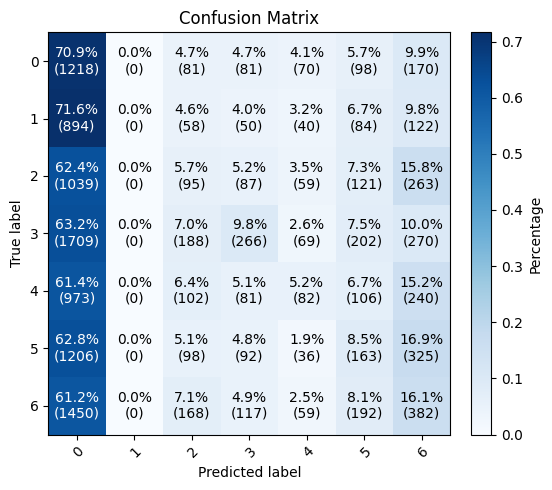

In [ ]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK test: 0.6552
              precision    recall  f1-score   support

           0       0.28      0.24      0.26        45
           1       1.00      0.20      0.34        59
           2       0.38      0.24      0.29        25
           3       0.72      1.00      0.84        69
           4       0.08      0.64      0.14        28
           5       1.00      0.77      0.87        83
           6       0.93      0.69      0.79       593

    accuracy                           0.66       902
   macro avg       0.63      0.54      0.50       902
weighted avg       0.85      0.66      0.71       902



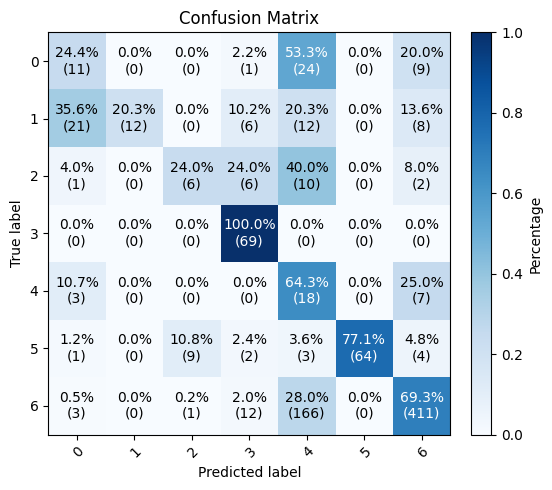

In [ ]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)